### วัดอัตรา การ ส่ง เทียบกับ การคืนสินค้า(ลูกค้าไม่รับสินค้า เสียรายได้)

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/clean/clean_data.csv")

In [19]:
All_Status_Rate = (
    df[df["Year"] == 2023]
    .groupby(["Shipping Status", "AgeGroup"])["OrderID"]
    .nunique()
    .unstack(fill_value=0)
)

print(All_Status_Rate)



AgeGroup         20-29  30-39  40-49  50-59  60+  <20
Shipping Status                                      
Delivered           44     45     51     58   64   13
In Transit          44     38     58     73   67   14
Returned            35     54     40     64   60   16
Unknown              4      1      9     14   12    3


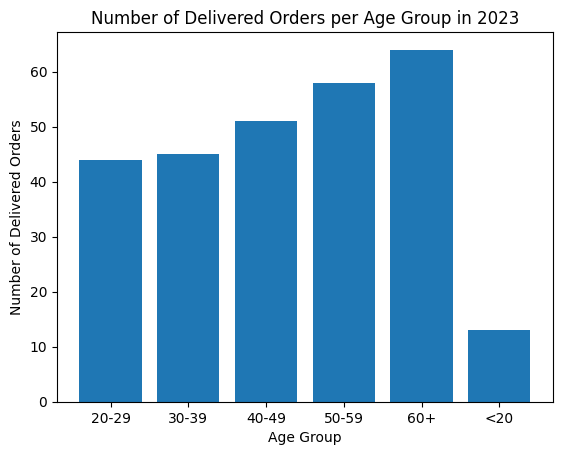

In [21]:
# Visualize Delivery rate per age group
plt.bar(All_Status_Rate.columns, All_Status_Rate.loc["Delivered"])
plt.xlabel("Age Group")
plt.ylabel("Number of Delivered Orders")
plt.title("Number of Delivered Orders per Age Group in 2023")
plt.show()


AgeGroup
30-39    0.392857
<20      0.347826
50-59    0.308411
60+      0.292683
20-29    0.282443
40-49    0.263804
Name: OrderID, dtype: float64


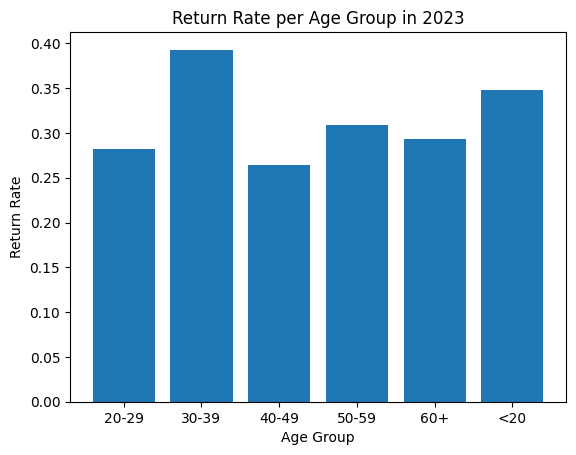

In [14]:
return_rate = (
    df[df["Shipping Status"] == "Returned"]
    .groupby("AgeGroup")["OrderID"]
    .nunique()
    /
    df.groupby("AgeGroup")["OrderID"].nunique()
)

print(return_rate.sort_values(ascending=False))

#Visualize the return rate per age group
plt.bar(return_rate.index, return_rate.values)
plt.xlabel("Age Group")
plt.ylabel("Return Rate")
plt.title("Return Rate per Age Group in 2023")
plt.show()

In [12]:
#Impact of Age Group on Revenue
order_per_ageGroup = (
    df[(df["Year"] == 2023) & (df["Shipping Status"] == "Delivered")]
    .groupby("AgeGroup")["OrderID"]
    .nunique()
    .sort_values(ascending=False)
)
print(order_per_ageGroup)

AgeGroup
60+      64
50-59    58
40-49    51
30-39    45
20-29    44
<20      13
Name: OrderID, dtype: int64
